# Regression-based physical copper price and certificate bubble

This notebook is an experimental alternative to ratio interpolation. It estimates IME physical copper price from free-market USD/IRR and LME cash copper USD/kg, compares a linear model with a degree-2 polynomial Ridge model using time-series cross-validation, and calculates the certificate bubble from the selected model. The production pipeline is not modified.

In [1]:
from bisect import bisect_right
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

## 1. Load the four source datasets

In [2]:
def first_existing(*candidates):
    path = next((Path(candidate) for candidate in candidates if Path(candidate).exists()), None)
    if path is None:
        raise FileNotFoundError(f"None of these paths exists: {candidates}")
    return path


certificate_path = first_existing(
    "../data/raw/certificate/copper_certificate_raw.csv",
    "commodity/copper/data/raw/certificate/copper_certificate_raw.csv",
)
physical_path = first_existing(
    "../data/processed/nci_copper_cash_daily.csv",
    "commodity/copper/data/processed/nci_copper_cash_daily.csv",
)
lme_path = first_existing(
    "../data/raw/lme/copper_lme_raw.csv",
    "commodity/copper/data/raw/lme/copper_lme_raw.csv",
)
usd_path = first_existing(
    "../data/raw/fx/usd_to_rial.csv",
    "commodity/copper/data/raw/fx/usd_to_rial.csv",
)

certificate_raw = pd.read_csv(certificate_path)
physical_daily = pd.read_csv(physical_path)
lme_raw = pd.read_csv(lme_path)
usd_raw = pd.read_csv(usd_path)

{
    "certificate_raw": certificate_raw.shape,
    "physical_daily": physical_daily.shape,
    "lme_raw": lme_raw.shape,
    "usd_raw": usd_raw.shape,
}

{'certificate_raw': (263, 32),
 'physical_daily': (794, 12),
 'lme_raw': (4714, 7),
 'usd_raw': (13074, 5)}

## 2. Clean dates and prices

Certificate price is daily VWAP (`TradesValue / TradesVolume`). LME is converted from USD/metric-tonne to USD/kg. Missing weekend or holiday LME/USD observations are joined backward, never from a future date.

In [3]:
certificate = certificate_raw.copy()
certificate["date"] = pd.to_datetime(certificate["DT"].str[:10])
for column in ["TradesVolume", "TradesValue", "TodaySettlementPrice"]:
    certificate[column] = pd.to_numeric(certificate[column], errors="raise")
certificate = certificate.loc[certificate["TradesVolume"] > 0].copy()
certificate["certificate_price"] = (
    certificate["TradesValue"] / certificate["TradesVolume"]
)
certificate["settlement_check_error"] = (
    certificate["certificate_price"] - certificate["TodaySettlementPrice"]
).abs()
assert certificate["settlement_check_error"].max() <= 0.500001
certificate = certificate[[
    "date", "certificate_price", "TradesVolume", "TradesValue"
]].sort_values("date")

physical = physical_daily.copy()
physical["date"] = pd.to_datetime(physical["physical_trade_date_gregorian"])
physical["physical_price"] = pd.to_numeric(
    physical["physical_weighted_price"], errors="raise"
)
physical = physical[["date", "physical_price", "total_quantity"]].sort_values("date")

lme = lme_raw.loc[lme_raw["cash_settlement"].astype(str).str.strip().ne("-")].copy()
lme["lme_source_date"] = pd.to_datetime(lme["date"])
lme["lme_usd_per_ton"] = pd.to_numeric(
    lme["cash_settlement"].astype(str).str.replace(",", "", regex=False),
    errors="raise",
)
lme["lme_usd_per_kg"] = lme["lme_usd_per_ton"] / 1_000
lme = lme[["lme_source_date", "lme_usd_per_kg"]].sort_values("lme_source_date")

def parse_mixed_gregorian(value):
    parts = [int(part) for part in str(value).replace("-", "/").split("/")]
    if parts[0] >= 1900:
        year, month, day = parts
    else:
        month, day, year = parts
    return pd.Timestamp(year=year, month=month, day=day)

usd = usd_raw.copy()
usd["usd_source_date"] = usd["date_gr"].map(parse_mixed_gregorian)
usd["usd_irr"] = pd.to_numeric(
    usd["price_irr"].astype(str).str.replace(",", "", regex=False),
    errors="raise",
)
usd = usd[["usd_source_date", "usd_irr"]].sort_values("usd_source_date")

assert certificate["date"].is_unique
assert physical["date"].is_unique
assert lme["lme_source_date"].is_unique
assert usd["usd_source_date"].is_unique

## 3. Add backward-looking LME and USD inputs

In [4]:
def add_market_inputs(frame):
    result = frame.sort_values("date").copy()
    result = pd.merge_asof(
        result,
        lme,
        left_on="date",
        right_on="lme_source_date",
        direction="backward",
    )
    result = pd.merge_asof(
        result.sort_values("date"),
        usd,
        left_on="date",
        right_on="usd_source_date",
        direction="backward",
    )
    result["lme_age_days"] = (result["date"] - result["lme_source_date"]).dt.days
    result["usd_age_days"] = (result["date"] - result["usd_source_date"]).dt.days
    result["intrinsic_price"] = result["lme_usd_per_kg"] * result["usd_irr"]
    if result[["lme_usd_per_kg", "usd_irr"]].isna().any().any():
        raise ValueError("Missing LME or USD inputs after backward merge")
    return result


# Regression training data comes only from the physical market, USD, and LME.
# The certificate dataset is not merged into the regression sample.
REGRESSION_START_DATE = pd.Timestamp("2025-11-12")
physical_regression_sample = physical.loc[
    physical["date"] >= REGRESSION_START_DATE
].copy()
anchors = add_market_inputs(physical_regression_sample)
assert not anchors.empty, "No physical observations found in the regression period"

# Certificate market inputs are prepared separately and are used only after fitting.
certificate_features = add_market_inputs(certificate)

anchors[[
    "date", "physical_price", "usd_irr", "lme_usd_per_kg", "intrinsic_price"
]]

,date,physical_price,usd_irr,lme_usd_per_kg,intrinsic_price
0,2025-11-23,"10,660,673.0000","1,132,000.0000",10.6855,"12,095,986.0000"
1,2025-12-17,"13,266,993.0000","1,310,800.0000",11.7200,"15,362,576.0000"
2,2026-03-29,"16,541,000.0000","1,585,600.0000",12.0460,"19,100,137.6000"
3,2026-03-30,"16,541,000.0000","1,585,600.0000",12.1370,"19,244,427.2000"
4,2026-04-05,"16,541,000.0000","1,527,800.0000",12.1470,"18,558,186.6000"
5,2026-04-12,"16,766,000.0000","1,553,100.0000",12.6605,"19,663,022.5500"
6,2026-04-13,"16,766,000.0000","1,578,300.0000",12.8205,"20,234,595.1500"
7,2026-04-19,"17,604,000.0000","1,507,300.0000",13.1490,"19,819,487.7000"
8,2026-04-26,"18,484,000.0000","1,569,500.0000",13.2300,"20,764,485.0000"
9,2026-05-03,"19,308,847.0000","1,869,000.0000",12.8950,"24,100,755.0000"


## 4. Compare linear and degree-2 polynomial regression

Only 25 physical-market observations are available, so the polynomial model is regularized with Ridge. `TimeSeriesSplit` preserves temporal order. Model selection uses the lowest out-of-sample RMSE. Certificate prices are not present in `X`, `y`, or the regression sample.

In [5]:
FEATURES = ["usd_irr", "lme_usd_per_kg"]
TARGET = "physical_price"

X = anchors[FEATURES]
y = anchors[TARGET]

models = {
    "linear": Pipeline([
        ("scale", StandardScaler()),
        ("model", LinearRegression()),
    ]),
    "polynomial_degree_2_ridge": Pipeline([
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("scale", StandardScaler()),
        ("model", RidgeCV(alphas=np.logspace(-4, 4, 81))),
    ]),
}

tscv = TimeSeriesSplit(n_splits=5)
comparison_rows = []
oos_predictions = {}

for name, model in models.items():
    prediction = pd.Series(np.nan, index=y.index, dtype=float)
    for train_index, test_index in tscv.split(X):
        fold_model = clone(model)
        fold_model.fit(X.iloc[train_index], y.iloc[train_index])
        prediction.iloc[test_index] = fold_model.predict(X.iloc[test_index])
    valid = prediction.notna()
    valid_prediction = prediction.loc[valid]
    actual = y.loc[valid]
    oos_predictions[name] = valid_prediction
    comparison_rows.append({
        "model": name,
        "oos_n": len(actual),
        "MAE": mean_absolute_error(actual, valid_prediction),
        "RMSE": mean_squared_error(actual, valid_prediction) ** 0.5,
        "R2": r2_score(actual, valid_prediction),
    })

model_comparison = pd.DataFrame(comparison_rows).sort_values("RMSE").reset_index(drop=True)
model_comparison

,model,oos_n,MAE,RMSE,R2
0,linear,25,"366,205.9820","487,586.4727",0.8926
1,polynomial_degree_2_ridge,25,"480,555.5236","788,222.2805",0.7193


## 5. Fit the selected model and inspect anchor fit

In [6]:
selected_model_name = model_comparison.loc[0, "model"]
selected_model = models[selected_model_name]
selected_model.fit(X, y)

anchors["fitted_physical_price"] = selected_model.predict(X)
anchors["fitted_error_pct"] = (
    anchors["fitted_physical_price"] / anchors["physical_price"] - 1
) * 100

print(f"Selected model: {selected_model_name}")
if selected_model_name == "polynomial_degree_2_ridge":
    print(f"Selected Ridge alpha: {selected_model.named_steps['model'].alpha_}")

anchors[[
    "date", "physical_price", "fitted_physical_price", "fitted_error_pct"
]]

Selected model: linear


,date,physical_price,fitted_physical_price,fitted_error_pct
0,2025-11-23,"10,660,673.0000","10,856,477.6971",1.8367
1,2025-12-17,"13,266,993.0000","13,854,955.0646",4.4318
2,2026-03-29,"16,541,000.0000","16,194,713.8354",-2.0935
3,2026-03-30,"16,541,000.0000","16,358,049.7477",-1.1060
4,2026-04-05,"16,541,000.0000","16,006,940.8426",-3.2287
5,2026-04-12,"16,766,000.0000","17,090,164.7096",1.9335
6,2026-04-13,"16,766,000.0000","17,538,252.8703",4.6061
7,2026-04-19,"17,604,000.0000","17,674,536.5378",0.4007
8,2026-04-26,"18,484,000.0000","18,217,075.7287",-1.4441
9,2026-05-03,"19,308,847.0000","19,528,117.1068",1.1356


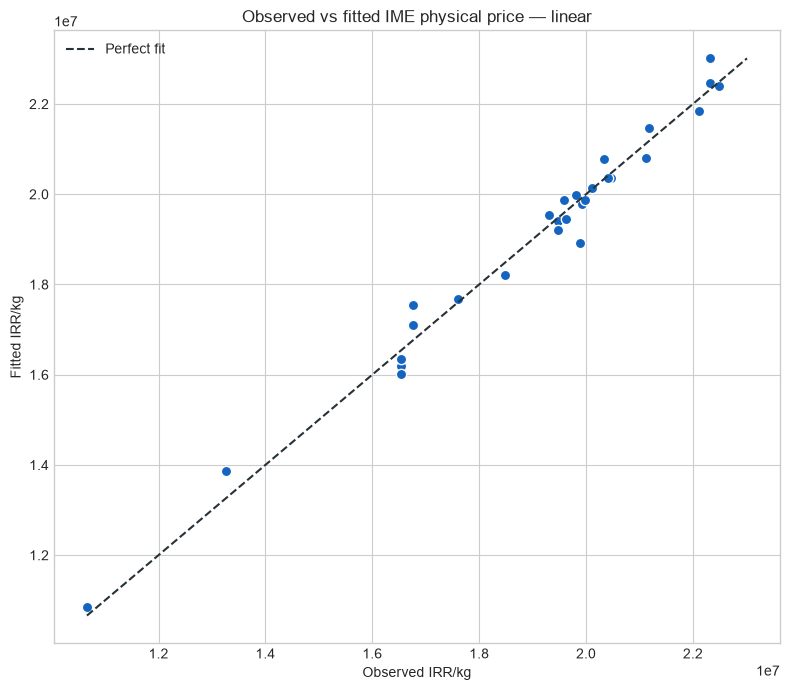

In [7]:
fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(
    anchors["physical_price"],
    anchors["fitted_physical_price"],
    s=55,
    color="#1565C0",
    edgecolor="white",
)
limits = [
    min(anchors["physical_price"].min(), anchors["fitted_physical_price"].min()),
    max(anchors["physical_price"].max(), anchors["fitted_physical_price"].max()),
]
ax.plot(limits, limits, "--", color="#263238", label="Perfect fit")
ax.set(
    title=f"Observed vs fitted IME physical price — {selected_model_name}",
    xlabel="Observed IRR/kg",
    ylabel="Fitted IRR/kg",
)
ax.legend()
fig.tight_layout()
plt.show()

## 6. Estimate physical price for all 159 certificate trading days and calculate bubble

Unlike linear ratio interpolation, regression can produce estimates before the first and after the last physical anchor. These are model estimates—not observed physical trades—and should be interpreted with the cross-validation results.

In [8]:
bubble_regression = certificate_features.copy()
bubble_regression["estimated_physical_price"] = selected_model.predict(
    bubble_regression[FEATURES]
)
if (bubble_regression["estimated_physical_price"] <= 0).any():
    raise ValueError("The selected regression produced a non-positive physical price")

bubble_regression["certificate_bubble_irr_per_kg"] = (
    bubble_regression["certificate_price"]
    - bubble_regression["estimated_physical_price"]
)
bubble_regression["certificate_bubble_pct"] = (
    bubble_regression["certificate_price"]
    / bubble_regression["estimated_physical_price"]
    - 1
) * 100
bubble_regression["is_physical_anchor_date"] = bubble_regression["date"].isin(anchors["date"])
bubble_regression["regression_model"] = selected_model_name

bubble_regression[[
    "date", "certificate_price", "estimated_physical_price",
    "certificate_bubble_pct", "is_physical_anchor_date"
]].describe(include="all")

,date,certificate_price,estimated_physical_price,certificate_bubble_pct,is_physical_anchor_date
count,190,190.0000,190.0000,190.0000,190
unique,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,False
freq,NaN,NaN,NaN,NaN,161
mean,2026-03-20 02:46:44.210526,"18,020,072.8351","17,171,602.1672",4.0274,NaN
min,2025-10-20 00:00:00,"10,205,657.0950","10,345,448.9819",-15.1450,NaN
25%,2025-12-27 06:00:00,"15,208,606.0056","15,238,318.1197",-2.1770,NaN
50%,2026-03-29 12:00:00,"17,806,983.7490","17,696,394.5937",3.4755,NaN
75%,2026-06-07 18:00:00,"22,161,057.2334","19,889,922.8790",10.7962,NaN
max,2026-08-22 00:00:00,"25,327,917.5715","23,011,606.5315",24.4072,NaN


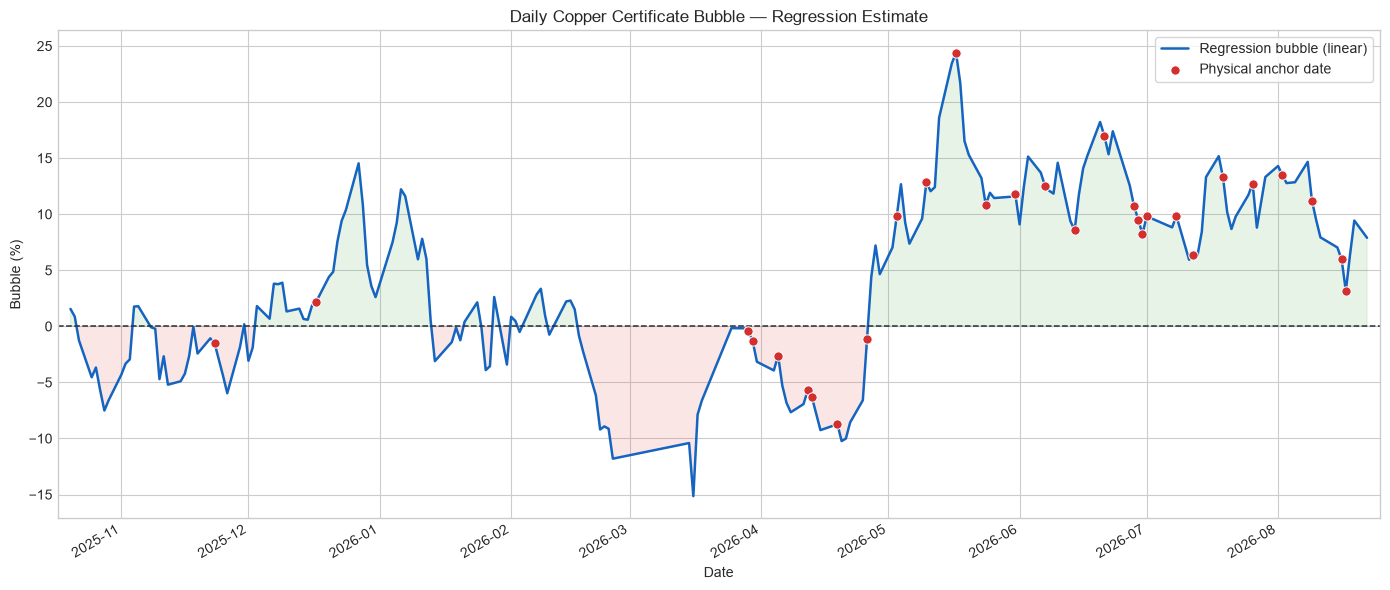

In [9]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(
    bubble_regression["date"],
    bubble_regression["certificate_bubble_pct"],
    color="#1565C0",
    linewidth=1.8,
    label=f"Regression bubble ({selected_model_name})",
)
anchor_bubbles = bubble_regression.loc[bubble_regression["is_physical_anchor_date"]]
ax.scatter(
    anchor_bubbles["date"],
    anchor_bubbles["certificate_bubble_pct"],
    color="#D32F2F",
    edgecolor="white",
    linewidth=0.7,
    s=45,
    zorder=3,
    label="Physical anchor date",
)
ax.axhline(0, color="#263238", linewidth=1.1, linestyle="--")
ax.fill_between(
    bubble_regression["date"],
    bubble_regression["certificate_bubble_pct"],
    0,
    where=bubble_regression["certificate_bubble_pct"].ge(0),
    color="#43A047",
    alpha=0.12,
    interpolate=True,
)
ax.fill_between(
    bubble_regression["date"],
    bubble_regression["certificate_bubble_pct"],
    0,
    where=bubble_regression["certificate_bubble_pct"].lt(0),
    color="#E53935",
    alpha=0.12,
    interpolate=True,
)
ax.set(
    title="Daily Copper Certificate Bubble — Regression Estimate",
    xlabel="Date",
    ylabel="Bubble (%)",
)
ax.legend(frameon=True)
ax.margins(x=0.01)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## 7. Optional: inspect or save the experimental result

The save command is intentionally commented out. Uncomment it only if the regression result is accepted after reviewing cross-validation diagnostics.

In [10]:
regression_output = bubble_regression[[
    "date",
    "certificate_price",
    "TradesVolume",
    "lme_source_date",
    "lme_age_days",
    "lme_usd_per_kg",
    "usd_source_date",
    "usd_age_days",
    "usd_irr",
    "intrinsic_price",
    "estimated_physical_price",
    "certificate_bubble_irr_per_kg",
    "certificate_bubble_pct",
    "is_physical_anchor_date",
    "regression_model",
]].copy()

regression_output.head()

# Optional save after reviewing model diagnostics:
# output_path = Path("data/processed/copper_certificate_bubble_regression.csv")
# output_path.parent.mkdir(parents=True, exist_ok=True)
# regression_output.to_csv(output_path, index=False, encoding="utf-8-sig")

,date,certificate_price,TradesVolume,lme_source_date,lme_age_days,lme_usd_per_kg,usd_source_date,usd_age_days,usd_irr,intrinsic_price,estimated_physical_price,certificate_bubble_irr_per_kg,certificate_bubble_pct,is_physical_anchor_date,regression_model
0,2025-10-20,"10,507,161.1641",57651,2025-10-20,0,10.5810,2025-10-20,0,"1,081,500.0000","11,443,351.5000","10,346,463.8462","160,697.3179",1.5532,False,linear
1,2025-10-21,"10,454,394.0267",26322,2025-10-21,0,10.6120,2025-10-21,0,"1,075,500.0000","11,413,206.0000","10,363,795.2411","90,598.7856",0.8742,False,linear
2,2025-10-22,"10,215,889.4684",90627,2025-10-22,0,10.6000,2025-10-22,0,"1,076,000.0000","11,405,600.0000","10,345,448.9819","-129,559.5135",-1.2523,False,linear
3,2025-10-25,"10,205,657.0950",13043,2025-10-24,1,10.8070,2025-10-25,0,"1,072,000.0000","11,585,104.0000","10,691,452.9703","-485,795.8753",-4.5438,False,linear
4,2025-10-26,"10,335,702.5324",70918,2025-10-24,2,10.8070,2025-10-26,0,"1,078,000.0000","11,649,946.0000","10,729,763.4797","-394,060.9473",-3.6726,False,linear


## 8. Approved interpolated-ratio certificate bubble

This section plots the previously calculated production output in `copper_certificate_bubble.csv`. It is kept separate from the experimental regression bubble above.

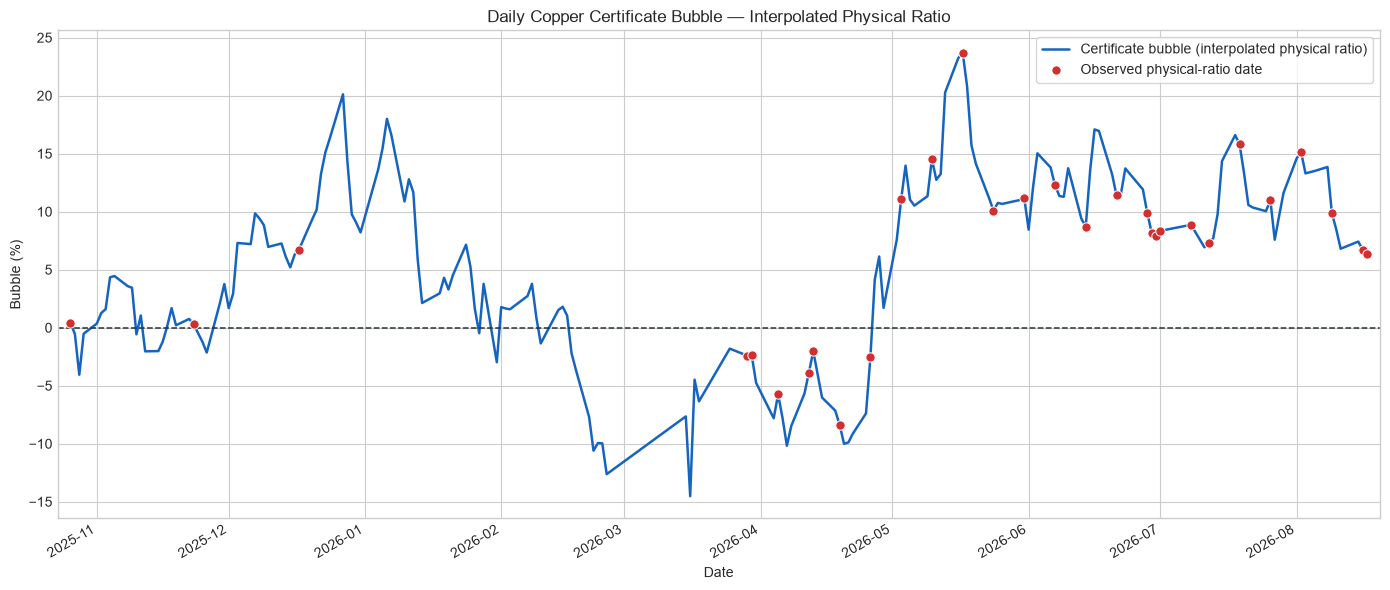

In [11]:
approved_bubble_path = first_existing(
    "../data/processed/copper_certificate_bubble.csv",
    "commodity/copper/data/processed/copper_certificate_bubble.csv",
)
approved_bubble = pd.read_csv(approved_bubble_path, parse_dates=["date"])
approved_bubble["certificate_bubble_pct"] = pd.to_numeric(
    approved_bubble["certificate_bubble_pct"], errors="raise"
)
approved_bubble = approved_bubble.sort_values("date").reset_index(drop=True)
approved_bubble["is_observed_ratio"] = approved_bubble["physical_ratio_method"].eq("observed")

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(
    approved_bubble["date"],
    approved_bubble["certificate_bubble_pct"],
    color="#1565C0",
    linewidth=1.8,
    label="Certificate bubble (interpolated physical ratio)",
)
observed_ratio_days = approved_bubble.loc[approved_bubble["is_observed_ratio"]]
ax.scatter(
    observed_ratio_days["date"],
    observed_ratio_days["certificate_bubble_pct"],
    color="#D32F2F",
    edgecolor="white",
    linewidth=0.7,
    s=45,
    zorder=3,
    label="Observed physical-ratio date",
)
ax.axhline(0, color="#263238", linestyle="--", linewidth=1.1)
ax.set(
    title="Daily Copper Certificate Bubble — Interpolated Physical Ratio",
    xlabel="Date",
    ylabel="Bubble (%)",
)
ax.legend(frameon=True)
ax.margins(x=0.01)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## 9. Observed IME physical-market premium over intrinsic copper value

For the 25 actual physical-market observations, intrinsic value is `LME cash USD/kg × free-market USD/IRR`. The plotted premium is `(observed physical price / intrinsic price - 1) × 100`.

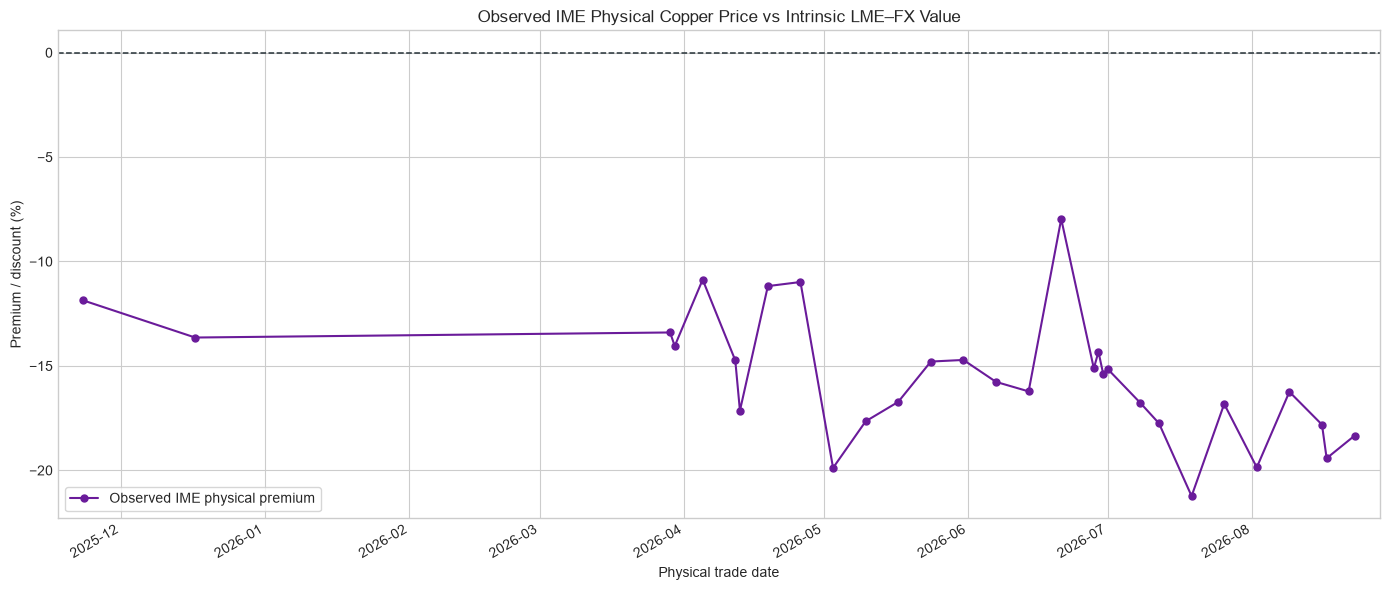

,date,physical_price,lme_usd_per_kg,usd_irr,intrinsic_price,physical_vs_intrinsic_bubble_pct
0,2025-11-23,"10,660,673.0000",10.6855,"1,132,000.0000","12,095,986.0000",-11.8660
1,2025-12-17,"13,266,993.0000",11.7200,"1,310,800.0000","15,362,576.0000",-13.6408
2,2026-03-29,"16,541,000.0000",12.0460,"1,585,600.0000","19,100,137.6000",-13.3985
3,2026-03-30,"16,541,000.0000",12.1370,"1,585,600.0000","19,244,427.2000",-14.0478
4,2026-04-05,"16,541,000.0000",12.1470,"1,527,800.0000","18,558,186.6000",-10.8695
5,2026-04-12,"16,766,000.0000",12.6605,"1,553,100.0000","19,663,022.5500",-14.7334
6,2026-04-13,"16,766,000.0000",12.8205,"1,578,300.0000","20,234,595.1500",-17.1419
7,2026-04-19,"17,604,000.0000",13.1490,"1,507,300.0000","19,819,487.7000",-11.1783
8,2026-04-26,"18,484,000.0000",13.2300,"1,569,500.0000","20,764,485.0000",-10.9826
9,2026-05-03,"19,308,847.0000",12.8950,"1,869,000.0000","24,100,755.0000",-19.8828


In [12]:
physical_intrinsic_bubble = anchors[[
    "date", "physical_price", "lme_usd_per_kg", "usd_irr", "intrinsic_price"
]].copy()
assert len(physical_intrinsic_bubble) == len(anchors)
physical_intrinsic_bubble["physical_vs_intrinsic_bubble_pct"] = (
    physical_intrinsic_bubble["physical_price"]
    / physical_intrinsic_bubble["intrinsic_price"]
    - 1
) * 100

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(
    physical_intrinsic_bubble["date"],
    physical_intrinsic_bubble["physical_vs_intrinsic_bubble_pct"],
    color="#6A1B9A",
    linewidth=1.5,
    marker="o",
    markersize=5,
    label="Observed IME physical premium",
)
ax.axhline(0, color="#263238", linestyle="--", linewidth=1.1)
ax.set(
    title="Observed IME Physical Copper Price vs Intrinsic LME–FX Value",
    xlabel="Physical trade date",
    ylabel="Premium / discount (%)",
)
ax.legend(frameon=True)
ax.margins(x=0.02)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

physical_intrinsic_bubble

## 10. Certificate premium over intrinsic copper value

This measure compares certificate VWAP directly with `LME cash USD/kg × free-market USD/IRR`; it does not use observed, interpolated, or regression-estimated IME physical price.

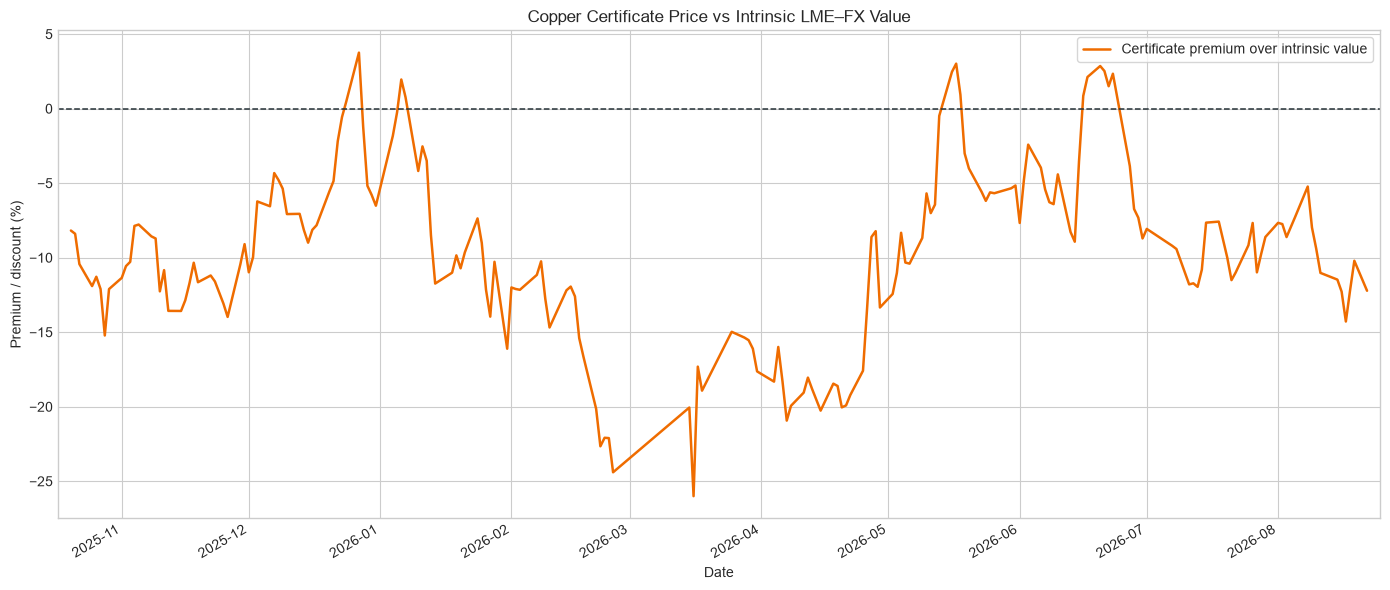

,date,certificate_price,lme_usd_per_kg,usd_irr,intrinsic_price,certificate_vs_intrinsic_bubble_pct
0,2025-10-20,"10,507,161.1641",10.5810,"1,081,500.0000","11,443,351.5000",-8.1811
1,2025-10-21,"10,454,394.0267",10.6120,"1,075,500.0000","11,413,206.0000",-8.4009
2,2025-10-22,"10,215,889.4684",10.6000,"1,076,000.0000","11,405,600.0000",-10.4309
3,2025-10-25,"10,205,657.0950",10.8070,"1,072,000.0000","11,585,104.0000",-11.9071
4,2025-10-26,"10,335,702.5324",10.8070,"1,078,000.0000","11,649,946.0000",-11.2811
...,...,...,...,...,...,...
185,2026-08-16,"23,818,113.4899",14.5450,"1,866,800.0000","27,152,606.0000",-12.2806
186,2026-08-17,"23,738,889.3343",14.8500,"1,865,000.0000","27,695,250.0000",-14.2853
187,2026-08-18,"23,541,959.7917",14.3350,"1,870,100.0000","26,807,883.5000",-12.1827
188,2026-08-19,"24,013,189.0102",14.1800,"1,886,000.0000","26,743,480.0000",-10.2092


In [13]:
certificate_intrinsic_bubble = certificate_features[[
    "date", "certificate_price", "lme_usd_per_kg", "usd_irr", "intrinsic_price"
]].copy()
certificate_intrinsic_bubble["certificate_vs_intrinsic_bubble_pct"] = (
    certificate_intrinsic_bubble["certificate_price"]
    / certificate_intrinsic_bubble["intrinsic_price"]
    - 1
) * 100

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(
    certificate_intrinsic_bubble["date"],
    certificate_intrinsic_bubble["certificate_vs_intrinsic_bubble_pct"],
    color="#EF6C00",
    linewidth=1.8,
    label="Certificate premium over intrinsic value",
)
ax.axhline(0, color="#263238", linestyle="--", linewidth=1.1)
ax.set(
    title="Copper Certificate Price vs Intrinsic LME–FX Value",
    xlabel="Date",
    ylabel="Premium / discount (%)",
)
ax.legend(frameon=True)
ax.margins(x=0.01)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

certificate_intrinsic_bubble

## 11. Full-history IME physical copper premium over intrinsic value

This section extends the physical-market analysis to the complete available history. It uses every positive-trade observation in `nci_copper_cash_daily.csv`, not only the recent certificate period. Intrinsic value is `LME cash USD/kg × free-market USD/IRR`.

In [14]:
physical_full_history = add_market_inputs(physical).copy()
physical_full_history["physical_vs_intrinsic_bubble_pct"] = (
    physical_full_history["physical_price"]
    / physical_full_history["intrinsic_price"]
    - 1
) * 100

assert len(physical_full_history) == len(physical)
assert physical_full_history["physical_vs_intrinsic_bubble_pct"].notna().all()

print(f"Physical observations: {len(physical_full_history):,}")
print(
    f"Coverage: {physical_full_history['date'].min().date()} "
    f"through {physical_full_history['date'].max().date()}"
)
physical_full_history[[
    "date",
    "physical_price",
    "lme_usd_per_kg",
    "usd_irr",
    "intrinsic_price",
    "physical_vs_intrinsic_bubble_pct",
]].describe(include="all")

Physical observations: 794
Coverage: 2008-08-24 through 2026-08-23


,date,physical_price,lme_usd_per_kg,usd_irr,intrinsic_price,physical_vs_intrinsic_bubble_pct
count,794,794.0000,794.0000,794.0000,794.0000,794.0000
mean,2017-03-23 22:12:59.848866,"1,750,993.7491",7.3789,"206,821.0592","2,048,909.9372",-8.4883
min,2008-08-24 00:00:00,"28,636.0000",2.7700,"9,670.0000","27,561.5000",-57.5203
25%,2012-12-17 18:00:00,"160,800.5000",5.9536,"29,495.2500","162,690.2700",-15.1025
50%,2017-01-25 12:00:00,"227,051.0000",7.0895,"37,640.0000","249,750.1875",-6.9718
75%,2021-07-02 06:00:00,"2,101,597.7500",8.5685,"260,216.2500","2,355,983.8844",-1.1470
max,2026-08-23 00:00:00,"22,488,000.0000",14.8500,"1,930,000.0000","27,695,250.0000",28.0412
std,NaN,"3,797,529.9621",2.0049,"354,452.8237","4,522,040.0290",10.5304


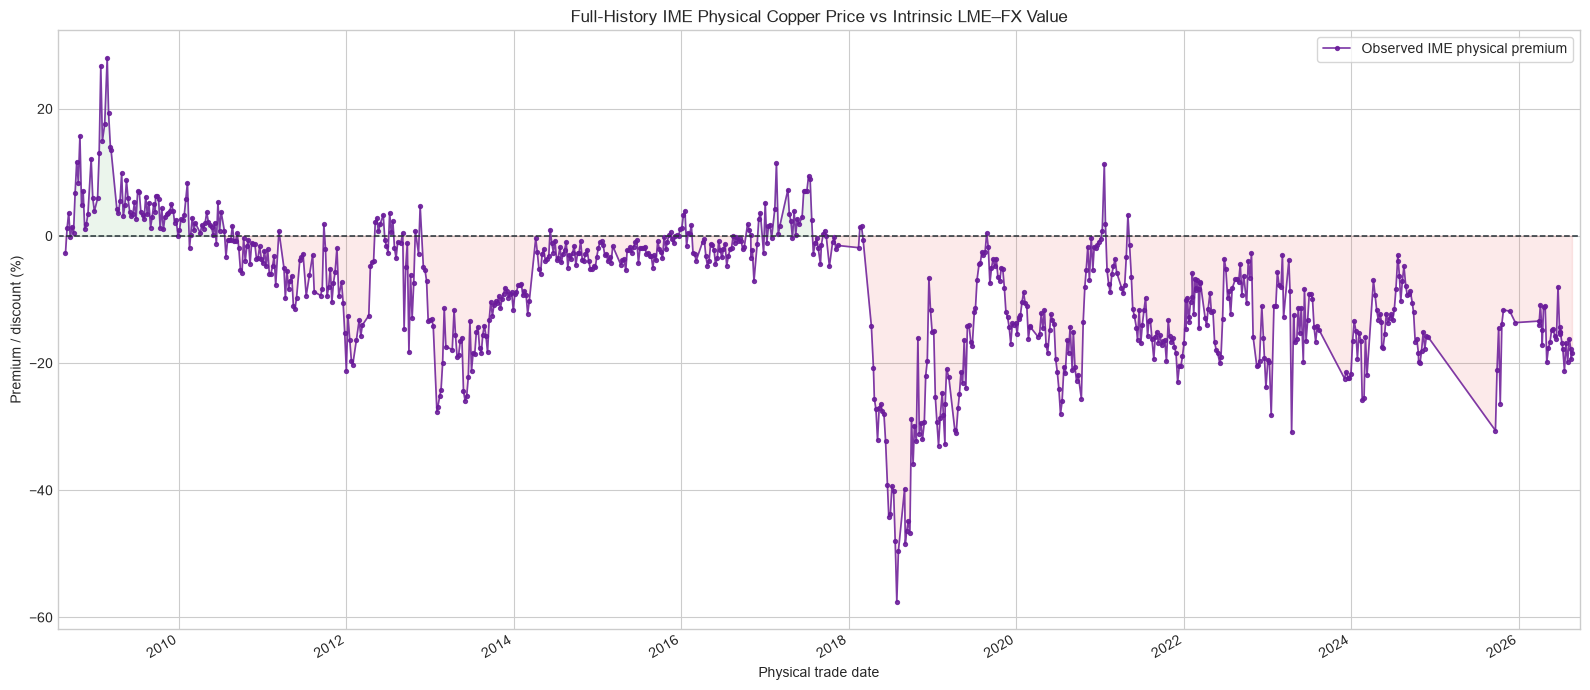

In [15]:
fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(
    physical_full_history["date"],
    physical_full_history["physical_vs_intrinsic_bubble_pct"],
    color="#6A1B9A",
    linewidth=1.25,
    marker="o",
    markersize=2.8,
    alpha=0.85,
    label="Observed IME physical premium",
)
ax.axhline(0, color="#263238", linestyle="--", linewidth=1.1)
ax.fill_between(
    physical_full_history["date"],
    physical_full_history["physical_vs_intrinsic_bubble_pct"],
    0,
    where=physical_full_history["physical_vs_intrinsic_bubble_pct"].ge(0),
    color="#43A047",
    alpha=0.10,
    interpolate=True,
)
ax.fill_between(
    physical_full_history["date"],
    physical_full_history["physical_vs_intrinsic_bubble_pct"],
    0,
    where=physical_full_history["physical_vs_intrinsic_bubble_pct"].lt(0),
    color="#E53935",
    alpha=0.10,
    interpolate=True,
)
ax.set(
    title="Full-History IME Physical Copper Price vs Intrinsic LME–FX Value",
    xlabel="Physical trade date",
    ylabel="Premium / discount (%)",
)
ax.legend(frameon=True)
ax.margins(x=0.005)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## 12. Corrected regression: physical price on intrinsic LME–FX value

This section supersedes the earlier experimental two-feature regression. The sole explanatory variable is intrinsic copper value: `LME cash USD/kg × free-market USD/IRR`. Certificate price is not used in model fitting. Three specifications are compared: proportional (no intercept), linear with intercept, and degree-2 polynomial Ridge.

In [16]:
INTRINSIC_FEATURE = ["intrinsic_price"]
X_intrinsic = anchors[INTRINSIC_FEATURE]
y_physical = anchors["physical_price"]

intrinsic_models = {
    "proportional_no_intercept": LinearRegression(fit_intercept=False),
    "linear_with_intercept": LinearRegression(),
    "polynomial_degree_2_ridge": Pipeline([
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("scale", StandardScaler()),
        ("model", RidgeCV(alphas=np.logspace(-4, 4, 81))),
    ]),
}

intrinsic_comparison_rows = []
intrinsic_oos_predictions = {}
intrinsic_tscv = TimeSeriesSplit(n_splits=5)

for name, model in intrinsic_models.items():
    prediction = pd.Series(np.nan, index=y_physical.index, dtype=float)
    for train_index, test_index in intrinsic_tscv.split(X_intrinsic):
        fold_model = clone(model)
        fold_model.fit(X_intrinsic.iloc[train_index], y_physical.iloc[train_index])
        prediction.iloc[test_index] = fold_model.predict(X_intrinsic.iloc[test_index])
    valid = prediction.notna()
    actual = y_physical.loc[valid]
    predicted = prediction.loc[valid]
    intrinsic_oos_predictions[name] = predicted
    intrinsic_comparison_rows.append({
        "model": name,
        "oos_n": len(actual),
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": mean_squared_error(actual, predicted) ** 0.5,
        "R2": r2_score(actual, predicted),
    })

intrinsic_model_comparison = (
    pd.DataFrame(intrinsic_comparison_rows)
    .sort_values("RMSE")
    .reset_index(drop=True)
)
intrinsic_model_comparison

,model,oos_n,MAE,RMSE,R2
0,linear_with_intercept,25,"442,198.7703","622,913.1490",0.8247
1,polynomial_degree_2_ridge,25,"520,944.8611","706,582.1562",0.7745
2,proportional_no_intercept,25,"609,398.9426","780,817.8753",0.7246


In [17]:
selected_intrinsic_model_name = intrinsic_model_comparison.loc[0, "model"]
selected_intrinsic_model = clone(intrinsic_models[selected_intrinsic_model_name])
selected_intrinsic_model.fit(X_intrinsic, y_physical)

anchors_intrinsic_regression = anchors.copy()
anchors_intrinsic_regression["fitted_physical_price"] = (
    selected_intrinsic_model.predict(anchors_intrinsic_regression[INTRINSIC_FEATURE])
)
anchors_intrinsic_regression["fitted_error_pct"] = (
    anchors_intrinsic_regression["fitted_physical_price"]
    / anchors_intrinsic_regression["physical_price"]
    - 1
) * 100

bubble_intrinsic_regression = certificate_features.copy()
bubble_intrinsic_regression["estimated_physical_price"] = (
    selected_intrinsic_model.predict(bubble_intrinsic_regression[INTRINSIC_FEATURE])
)
if (bubble_intrinsic_regression["estimated_physical_price"] <= 0).any():
    raise ValueError("The selected intrinsic regression produced a non-positive price")
bubble_intrinsic_regression["certificate_bubble_pct"] = (
    bubble_intrinsic_regression["certificate_price"]
    / bubble_intrinsic_regression["estimated_physical_price"]
    - 1
) * 100
bubble_intrinsic_regression["is_physical_anchor_date"] = (
    bubble_intrinsic_regression["date"].isin(anchors["date"])
)

print(f"Selected corrected model: {selected_intrinsic_model_name}")
anchors_intrinsic_regression[[
    "date", "intrinsic_price", "physical_price",
    "fitted_physical_price", "fitted_error_pct"
]]

Selected corrected model: linear_with_intercept


,date,intrinsic_price,physical_price,fitted_physical_price,fitted_error_pct
0,2025-11-23,"12,095,986.0000","10,660,673.0000","11,441,246.3877",7.3220
1,2025-12-17,"15,362,576.0000","13,266,993.0000","13,800,497.9935",4.0213
2,2026-03-29,"19,100,137.6000","16,541,000.0000","16,499,902.6346",-0.2485
3,2026-03-30,"19,244,427.2000","16,541,000.0000","16,604,113.8979",0.3816
4,2026-04-05,"18,558,186.6000","16,541,000.0000","16,108,485.6624",-2.6148
5,2026-04-12,"19,663,022.5500","16,766,000.0000","16,906,438.8764",0.8376
6,2026-04-13,"20,234,595.1500","16,766,000.0000","17,319,249.6590",3.2998
7,2026-04-19,"19,819,487.7000","17,604,000.0000","17,019,443.7703",-3.3206
8,2026-04-26,"20,764,485.0000","18,484,000.0000","17,701,955.6244",-4.2309
9,2026-05-03,"24,100,755.0000","19,308,847.0000","20,111,532.6925",4.1571


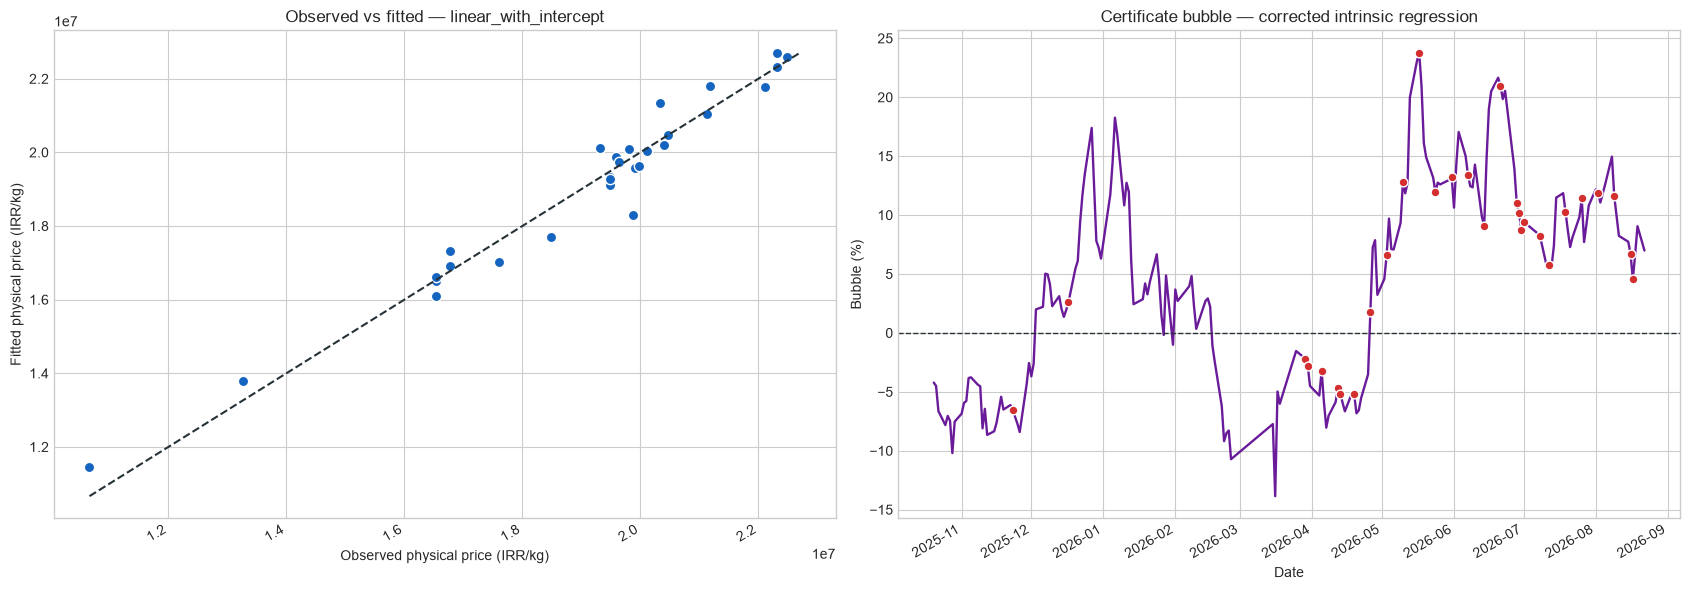

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

axes[0].scatter(
    anchors_intrinsic_regression["physical_price"],
    anchors_intrinsic_regression["fitted_physical_price"],
    color="#1565C0",
    edgecolor="white",
    s=55,
)
fit_limits = [
    min(anchors_intrinsic_regression["physical_price"].min(), anchors_intrinsic_regression["fitted_physical_price"].min()),
    max(anchors_intrinsic_regression["physical_price"].max(), anchors_intrinsic_regression["fitted_physical_price"].max()),
]
axes[0].plot(fit_limits, fit_limits, "--", color="#263238")
axes[0].set(
    title=f"Observed vs fitted — {selected_intrinsic_model_name}",
    xlabel="Observed physical price (IRR/kg)",
    ylabel="Fitted physical price (IRR/kg)",
)

axes[1].plot(
    bubble_intrinsic_regression["date"],
    bubble_intrinsic_regression["certificate_bubble_pct"],
    color="#6A1B9A",
    linewidth=1.7,
)
anchor_regression_bubbles = bubble_intrinsic_regression.loc[
    bubble_intrinsic_regression["is_physical_anchor_date"]
]
axes[1].scatter(
    anchor_regression_bubbles["date"],
    anchor_regression_bubbles["certificate_bubble_pct"],
    color="#D32F2F",
    edgecolor="white",
    s=40,
    zorder=3,
)
axes[1].axhline(0, color="#263238", linestyle="--", linewidth=1.0)
axes[1].set(
    title="Certificate bubble — corrected intrinsic regression",
    xlabel="Date",
    ylabel="Bubble (%)",
)

fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## 10. Forward trades inside the 102-day cash gap

The gap is a gap in the exact NCI copper-cathode cash benchmark, not a market closure. This section isolates exact-symbol forward trades strictly inside the gap and compares their weighted prices with the last cash price before the gap, the first cash price after it, and a straight-line bridge between those two cash anchors.

In [19]:
forward_gap_path = first_existing(
    "../data/processed/nci_copper_forward_gap.csv",
    "commodity/copper/data/processed/nci_copper_forward_gap.csv",
)
forward_gap = pd.read_csv(forward_gap_path)
forward_gap["date"] = pd.to_datetime(forward_gap["trade_date_gregorian"])

forward_gap_summary = pd.Series(
    {
        "forward trade dates": len(forward_gap),
        "total quantity (t)": forward_gap["total_quantity"].sum(),
        "quantity-weighted price (IRR/kg)": np.average(
            forward_gap["forward_weighted_price"],
            weights=forward_gap["total_quantity"],
        ),
        "previous cash price (IRR/kg)": forward_gap["previous_cash_price"].iloc[0],
        "next cash price (IRR/kg)": forward_gap["next_cash_price"].iloc[0],
    },
    name="value",
)
display(forward_gap_summary.to_frame())
display(
    forward_gap[
        [
            "trade_date_jalali",
            "contract_types",
            "total_quantity",
            "forward_weighted_price",
            "vs_previous_cash_pct",
            "vs_next_cash_pct",
            "vs_linear_bridge_pct",
        ]
    ].round(2)
)

,value
forward trade dates,16.0000
total quantity (t),"26,420.0000"
quantity-weighted price (IRR/kg),"16,327,124.9054"
previous cash price (IRR/kg),"13,266,993.0000"
next cash price (IRR/kg),"16,541,000.0000"


,trade_date_jalali,contract_types,total_quantity,forward_weighted_price,vs_previous_cash_pct,vs_next_cash_pct,vs_linear_bridge_pct
0,1404/10/01,سلف,3000,14216860,7.1600,-14.0500,5.8800
1,1404/10/07,سلف,3000,16077020,21.1800,-2.8100,18.0400
2,1404/10/15,سلف|سلف (مچینگ),3000,15834000,19.3500,-4.2700,14.1000
3,1404/10/21,سلف|سلف (مچینگ),3000,15834000,19.3500,-4.2700,12.5400
4,1404/10/29,سلف|سلف (مچینگ),2520,16626000,25.3200,0.5100,16.0500
5,1404/11/05,سلف|سلف (مچینگ),2360,16340000,23.1600,-1.2200,12.5400
6,1404/11/12,سلف|سلف (مچینگ),3000,16892000,27.3200,2.1200,14.5700
7,1404/11/19,سلف|سلف (مچینگ),2200,17601000,32.6700,6.4100,17.5900
8,1404/11/20,سلف (مچینگ),180,17601000,32.6700,6.4100,17.3400
9,1404/11/21,سلف (مچینگ),20,17601000,32.6700,6.4100,17.0900


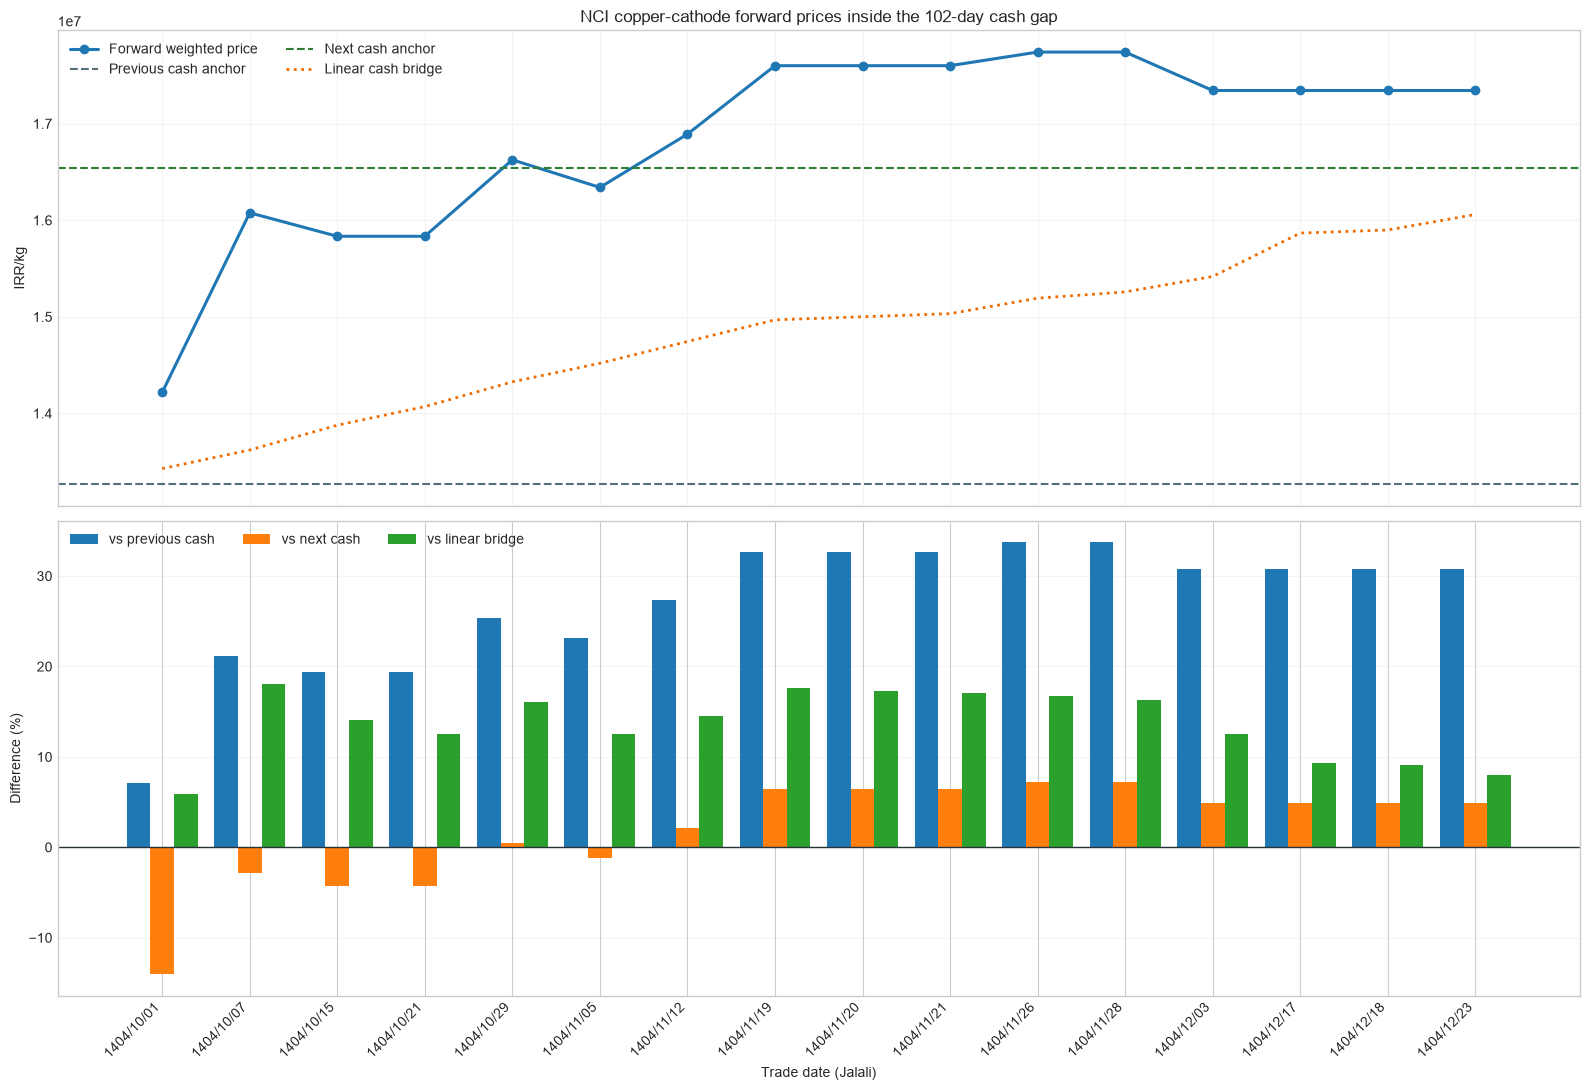

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(16, 11), sharex=True)
x = np.arange(len(forward_gap))

axes[0].plot(x, forward_gap["forward_weighted_price"], marker="o", linewidth=2.2, label="Forward weighted price")
axes[0].axhline(forward_gap["previous_cash_price"].iloc[0], color="#546E7A", linestyle="--", label="Previous cash anchor")
axes[0].axhline(forward_gap["next_cash_price"].iloc[0], color="#2E7D32", linestyle="--", label="Next cash anchor")
axes[0].plot(x, forward_gap["linear_cash_bridge_price"], color="#EF6C00", linestyle=":", linewidth=2.0, label="Linear cash bridge")
axes[0].set(title="NCI copper-cathode forward prices inside the 102-day cash gap", ylabel="IRR/kg")
axes[0].legend(ncol=2)
axes[0].grid(alpha=0.2)

width = 0.27
axes[1].bar(x - width, forward_gap["vs_previous_cash_pct"], width, label="vs previous cash")
axes[1].bar(x, forward_gap["vs_next_cash_pct"], width, label="vs next cash")
axes[1].bar(x + width, forward_gap["vs_linear_bridge_pct"], width, label="vs linear bridge")
axes[1].axhline(0, color="#263238", linewidth=1.0)
axes[1].set(ylabel="Difference (%)", xlabel="Trade date (Jalali)")
axes[1].set_xticks(x, forward_gap["trade_date_jalali"], rotation=45, ha="right")
axes[1].legend(ncol=3)
axes[1].grid(axis="y", alpha=0.2)

fig.tight_layout()
plt.show()

**Interpretation.** The 16 forward-trade dates total 26,420 tonnes. Forward prices range from 7.16% to 33.73% above the previous cash anchor and from 14.05% below to 7.26% above the next cash anchor. These observations are forward contracts with cash/credit settlement terms; they should not be inserted into the primary cash-only benchmark without explicit maturity and financing adjustments.

## 11. Certificate trading volume through time

The table and chart use every positive-volume copper-cathode certificate trading day in the canonical certificate input. Volume is the number of traded warehouse receipts reported by IME.

In [21]:
certificate_volume_history = (
    certificate[["date", "TradesVolume", "TradesValue"]]
    .rename(
        columns={
            "TradesVolume": "certificate_trades_volume",
            "TradesValue": "certificate_trades_value_irr",
        }
    )
    .sort_values("date")
    .reset_index(drop=True)
)
assert certificate_volume_history["certificate_trades_volume"].gt(0).all()
display(certificate_volume_history)

,date,certificate_trades_volume,certificate_trades_value_irr
0,2025-10-20,57651,605748348270
1,2025-10-21,26322,275180559570
2,2025-10-22,90627,925835414850
3,2025-10-25,13043,133112385490
4,2025-10-26,70918,732987352190
...,...,...,...
185,2026-08-16,14327,341242111970
186,2026-08-17,30554,725318024720
187,2026-08-18,25542,601308737000
188,2026-08-19,114078,2739376575910


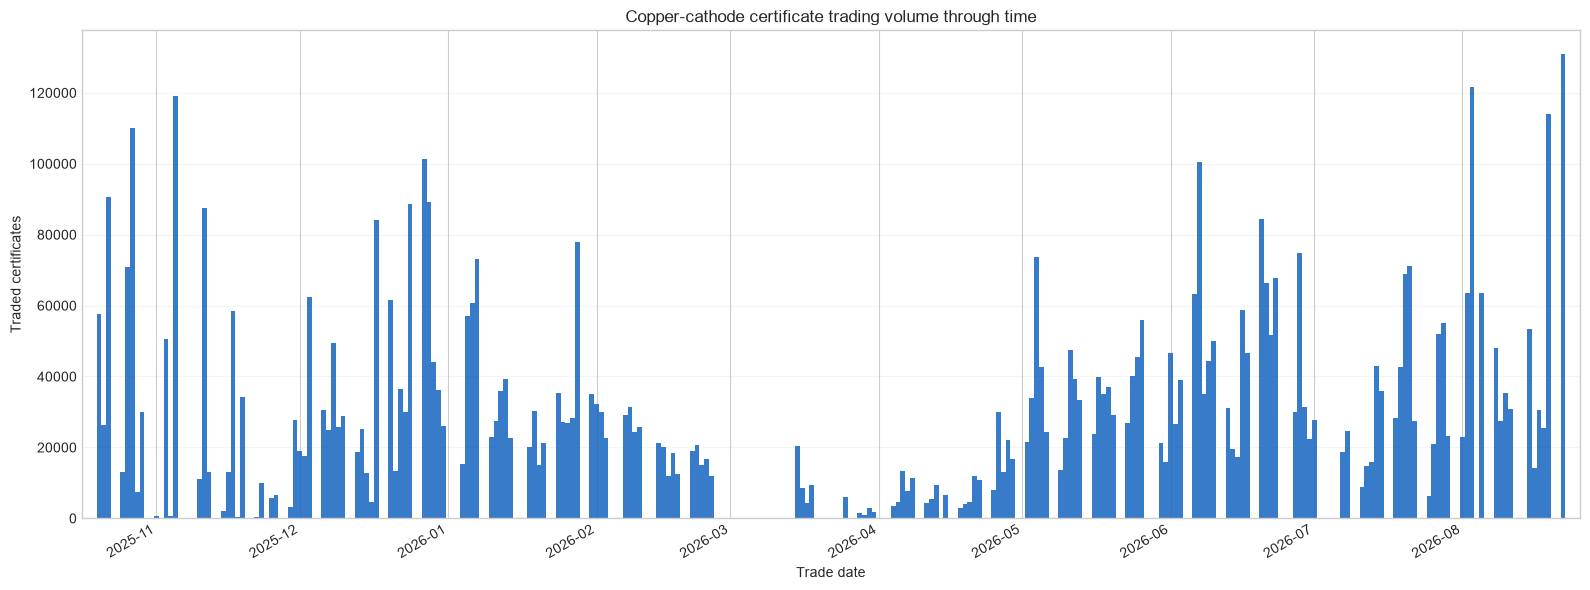

In [22]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(
    certificate_volume_history["date"],
    certificate_volume_history["certificate_trades_volume"],
    width=1.0,
    color="#1565C0",
    alpha=0.85,
)
ax.set(
    title="Copper-cathode certificate trading volume through time",
    xlabel="Trade date",
    ylabel="Traded certificates",
)
ax.grid(axis="y", alpha=0.2)
ax.margins(x=0.01)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## 12. Certificate bubble on the 28 jointly observed dates only

This diagnostic removes all interpolated dates. Bubble is recalculated only when certificate and comparable NCI cash physical prices are both observed on the same day: `(certificate price / observed physical price - 1) × 100`.

In [23]:
observed_certificate_bubble = approved_bubble.loc[
    approved_bubble["physical_ratio_method"].eq("observed"),
    [
        "date",
        "certificate_trades_volume",
        "certificate_price_irr_per_kg",
        "observed_physical_price_irr_per_kg",
    ],
].copy()
observed_certificate_bubble["observed_certificate_bubble_irr_per_kg"] = (
    observed_certificate_bubble["certificate_price_irr_per_kg"]
    - observed_certificate_bubble["observed_physical_price_irr_per_kg"]
)
observed_certificate_bubble["observed_certificate_bubble_pct"] = (
    observed_certificate_bubble["certificate_price_irr_per_kg"]
    / observed_certificate_bubble["observed_physical_price_irr_per_kg"]
    - 1
) * 100
observed_certificate_bubble = observed_certificate_bubble.sort_values("date").reset_index(drop=True)
assert len(observed_certificate_bubble) == approved_bubble["physical_ratio_method"].eq("observed").sum()
display(observed_certificate_bubble.round(2))

C:\Users\User\AppData\Local\Temp\ipykernel_15872\656558480.py:21: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(observed_certificate_bubble.round(2))


,date,certificate_trades_volume,certificate_price_irr_per_kg,observed_physical_price_irr_per_kg,observed_certificate_bubble_irr_per_kg,observed_certificate_bubble_pct
0,2025-10-26,70918,10335703,"10,296,373.0000","39,330.0000",0.3800
1,2025-11-23,10106,10693107,"10,660,673.0000","32,434.0000",0.3000
2,2025-12-17,84189,14160408,"13,266,993.0000","893,415.0000",6.7300
3,2026-03-29,838,16132371,"16,541,000.0000","-408,629.0000",-2.4700
4,2026-03-30,2816,16144178,"16,541,000.0000","-396,822.0000",-2.4000
5,2026-04-05,4547,15590354,"16,541,000.0000","-950,646.0000",-5.7500
6,2026-04-12,5364,16114179,"16,766,000.0000","-651,821.0000",-3.8900
7,2026-04-13,9273,16425974,"16,766,000.0000","-340,026.0000",-2.0300
8,2026-04-19,4110,16130906,"17,604,000.0000","-1,473,094.0000",-8.3700
9,2026-04-26,30123,18010209,"18,484,000.0000","-473,791.0000",-2.5600


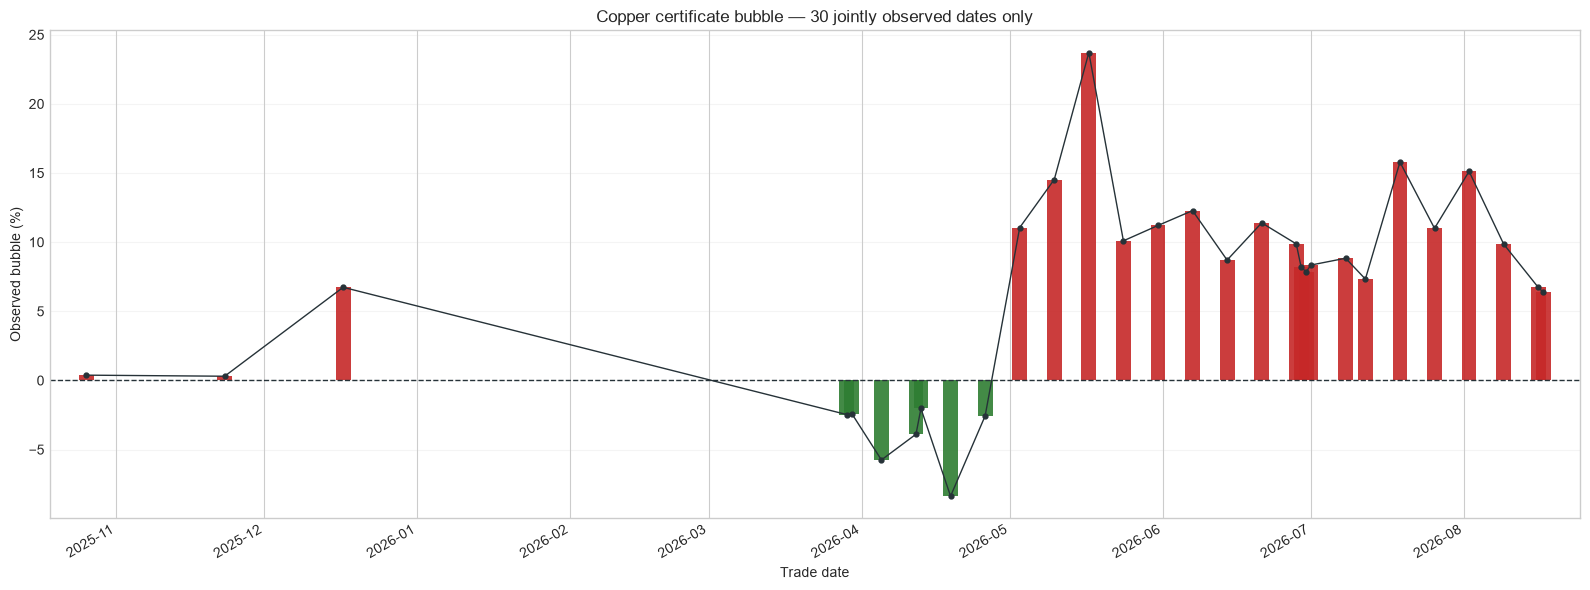

In [24]:
fig, ax = plt.subplots(figsize=(16, 6))
colors = np.where(
    observed_certificate_bubble["observed_certificate_bubble_pct"].ge(0),
    "#C62828",
    "#2E7D32",
)
ax.bar(
    observed_certificate_bubble["date"],
    observed_certificate_bubble["observed_certificate_bubble_pct"],
    width=3.0,
    color=colors,
    alpha=0.9,
)
ax.plot(
    observed_certificate_bubble["date"],
    observed_certificate_bubble["observed_certificate_bubble_pct"],
    color="#263238",
    linewidth=1.0,
    marker="o",
    markersize=3.5,
)
ax.axhline(0, color="#263238", linestyle="--", linewidth=1.0)
ax.set(
    title=f"Copper certificate bubble — {len(observed_certificate_bubble)} jointly observed dates only",
    xlabel="Trade date",
    ylabel="Observed bubble (%)",
)
ax.grid(axis="y", alpha=0.2)
ax.margins(x=0.02)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()